# 📈 Bölüm 2 — Marketing Ekibi: Facebook Reklam Performansı

**Hedef:** Kampanya bazında harcamanın nereye gittiğini, hangi kampanyanın gerçekten para kazandırdığını ve bütçenin nasıl yeniden dağıtılması gerektiğini ortaya koymak.

**İzleyeceğimiz yol:**
1. Veriyi yükleme ve tanıma
2. Metrik doğrulama — "verilen sayılar doğru mu?"
3. Sıfır günlerin teşhisi (hata mı, duraklama mı?)
4. ROAS vs ROMI — en sık yapılan terim hatası
5. Kampanya performans tablosu (ağırlıklı ortalama dersi)
6. Zaman serisi ve trend analizi
7. Bütçe dağılımı, Pareto ve verimlilik matrisi
8. İş yorumu ve bütçe önerisi

> 💡 **Bu bölümün en kritik dersi:** Oran metriklerinin (CTR, CPC, ROMI) ortalaması alınmaz — toplamlardan yeniden hesaplanır. Bunu atlayan analist yanlış kampanyaya bütçe verir.

---
## 1. Kurulum ve veriyi yükleme

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13

In [6]:
# Dosya notebook ile aynı klasördeyse sadece dosya adı yeterli
PATH_FB = 'facebook_ads_data (2.0).csv'

fb_raw = pd.read_csv(PATH_FB)
print('Boyut:', fb_raw.shape)
fb_raw.head()

Boyut: (1494, 10)


,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
0,2022-11-05,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
1,2022-11-01,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
2,2022-10-31,Expansion,227.45,6054,58,191.87,3.92,37.57,0.01,0.84
3,2022-10-30,Expansion,335.91,27562,69,472.61,4.87,12.19,0.00,1.41
4,2022-10-29,Expansion,714.03,33358,115,680.34,6.21,21.41,0.00,0.95


### Sütunlar ne anlama geliyor?

| Sütun | Anlamı | Türü |
|---|---|---|
| `ad_date` | Reklamın yayınlandığı gün | Boyut (dimension) |
| `campaign_name` | Kampanya adı | Boyut |
| `total_spend` | O gün harcanan reklam bütçesi | **Toplanabilir** |
| `total_impressions` | Gösterim sayısı | **Toplanabilir** |
| `total_clicks` | Tıklama sayısı | **Toplanabilir** |
| `total_value` | Reklamdan elde edilen gelir | **Toplanabilir** |
| `cpc` | Tıklama başına maliyet | ⚠️ **Oran — toplanamaz** |
| `cpm` | 1000 gösterim başına maliyet | ⚠️ **Oran — toplanamaz** |
| `ctr` | Tıklama oranı | ⚠️ **Oran — toplanamaz** |
| `romi` | Yatırım getirisi | ⚠️ **Oran — toplanamaz** |

Bu ayrım her reklam analizinin temelidir. Toplanabilir sütunlar `sum()` ile birleştirilir; oranlar ise **birleştirilmiş toplamlardan yeniden hesaplanır**.

In [7]:
fb_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ad_date            1494 non-null   str    
 1   campaign_name      1494 non-null   str    
 2   total_spend        1494 non-null   float64
 3   total_impressions  1494 non-null   int64  
 4   total_clicks       1494 non-null   int64  
 5   total_value        1494 non-null   float64
 6   cpc                1443 non-null   float64
 7   cpm                1462 non-null   float64
 8   ctr                1462 non-null   float64
 9   romi               1462 non-null   float64
dtypes: float64(6), int64(2), str(2)
memory usage: 144.3 KB


In [8]:
eksik = pd.DataFrame({
    'eksik_adet': fb_raw.isna().sum(),
    'eksik_yuzde': (fb_raw.isna().mean() * 100).round(2)
})
eksik[eksik['eksik_adet'] > 0]

,eksik_adet,eksik_yuzde
cpc,51,3.41
cpm,32,2.14
ctr,32,2.14
romi,32,2.14


🔎 Eksikler **sadece oran sütunlarında**. Bu bir tesadüf değil: paydası sıfır olan bir bölme (`0 tıklama` → CPC hesaplanamaz) `NaN` üretir. Yani eksik değerler veri kaybı değil, **matematiksel bir sonuç**. Bunu birazdan doğrulayacağız.

In [9]:
print('Kampanya sayısı:', fb_raw['campaign_name'].nunique())
fb_raw['campaign_name'].value_counts().to_frame('gun_sayisi')

Kampanya sayısı: 11


,gun_sayisi
campaign_name,
Lookalike,235
Wholesale,202
Electronics,174
Promos,145
Crazy discounts,124
Expansion,116
Hobbies,103
Discounts,101
Brand,100


---
## 2. Temizlik ve metrik doğrulama

### 2.1 Tarih dönüşümü ve tekrar kontrolü

Bu veri setinde bir satır = bir kampanyanın bir günü. Yani `(ad_date, campaign_name)` ikilisi **benzersiz olmalı**. Değilse aynı gün iki kez sayılır ve tüm toplamlar şişer.

In [10]:
fb = fb_raw.copy()
fb['ad_date'] = pd.to_datetime(fb['ad_date'])

print('Çevrilemeyen tarih :', fb['ad_date'].isna().sum())
print('Tarih aralığı      :', fb['ad_date'].min().date(), '->', fb['ad_date'].max().date())
print('Tamamen aynı satır :', fb.duplicated().sum())
print('Aynı gün+kampanya  :', fb.duplicated(subset=['ad_date', 'campaign_name']).sum())

Çevrilemeyen tarih : 0
Tarih aralığı      : 2020-11-11 -> 2022-11-05
Tamamen aynı satır : 0
Aynı gün+kampanya  : 0


In [11]:
# Zaman bazlı analiz için türetilmiş sütunlar
fb['yil']  = fb['ad_date'].dt.year
fb['ay']   = fb['ad_date'].dt.to_period('M').astype(str)
fb['hafta_gunu'] = fb['ad_date'].dt.day_name()

fb['yil'].value_counts().sort_index().to_frame('kayit_sayisi')

,kayit_sayisi
yil,
2020,53
2021,1167
2022,274


### 2.2 Mantık kontrolleri

Veriye güvenmeden önce **fiziksel olarak imkânsız** durumları ararız. Hepsi 0 çıkmalı.

In [12]:
kontroller = {
    'Negatif harcama'                 : (fb['total_spend'] < 0).sum(),
    'Negatif gelir'                   : (fb['total_value'] < 0).sum(),
    'Tıklama > gösterim'              : (fb['total_clicks'] > fb['total_impressions']).sum(),
    'Tıklama var ama gösterim yok'    : ((fb['total_clicks'] > 0) & (fb['total_impressions'] == 0)).sum(),
    'Tıklama var ama harcama yok'     : ((fb['total_clicks'] > 0) & (fb['total_spend'] == 0)).sum(),
    'Gelir var ama harcama yok'       : ((fb['total_value'] > 0) & (fb['total_spend'] == 0)).sum(),
}
pd.Series(kontroller).to_frame('adet')

,adet
Negatif harcama,0
Negatif gelir,0
Tıklama > gösterim,0
Tıklama var ama gösterim yok,0
Tıklama var ama harcama yok,0
Gelir var ama harcama yok,0


Hepsi sıfır ✅ — veri iç tutarlılık açısından sağlam. Bu kontrolleri yapmadan analize başlamak, temeli kontrol etmeden bina dikmeye benzer.

### 2.3 Verilen metrikler doğru hesaplanmış mı?

Reklam platformlarından gelen hazır metriklere **körü körüne güvenmeyin**. Formülleri kendiniz uygulayıp karşılaştırın:

$$CPC = \frac{Harcama}{Tıklama} \qquad CPM = \frac{Harcama}{Gösterim} \times 1000 \qquad CTR = \frac{Tıklama}{Gösterim}$$

In [13]:
# Sıfıra bölmeyi engellemek için sadece anlamlı satırlarda karşılaştırıyoruz
k = fb[(fb['total_clicks'] > 0) & (fb['total_impressions'] > 0) & (fb['total_spend'] > 0)].copy()

k['cpc_hesap']  = k['total_spend'] / k['total_clicks']
k['cpm_hesap']  = k['total_spend'] / k['total_impressions'] * 1000
k['ctr_hesap']  = k['total_clicks'] / k['total_impressions']
k['romi_hesap'] = k['total_value'] / k['total_spend']

dogrulama = pd.DataFrame({
    'max_fark': [
        (k['cpc']  - k['cpc_hesap']).abs().max(),
        (k['cpm']  - k['cpm_hesap']).abs().max(),
        (k['ctr']  - k['ctr_hesap']).abs().max(),
        (k['romi'] - k['romi_hesap']).abs().max(),
    ]
}, index=['cpc', 'cpm', 'ctr', 'romi'])
dogrulama['yorum'] = np.where(dogrulama['max_fark'] < 0.01, '✅ tutarlı', '❌ İNCELE')
dogrulama

,max_fark,yorum
cpc,0.01,✅ tutarlı
cpm,0.00,✅ tutarlı
ctr,0.00,✅ tutarlı
romi,0.00,✅ tutarlı


CPC ve CPM'deki ~0.005'lik fark **yuvarlamadan** kaynaklanıyor (iki ondalığa yuvarlanmışlar), gerçek bir hata değil. CTR ve ROMI tam tutuyor.

> ⚠️ **Kritik bulgu:** `romi` sütunu aslında `total_value / total_spend` formülüyle hesaplanmış. Bu **ROAS**'tır (Return on Ad Spend), ROMI değil. Gerçek ROMI formülü `(gelir - harcama) / harcama` şeklindedir ve bu veri setindeki değerlerden tam **1.0** daha düşük çıkar. Bunu bir sonraki adımda ayıklayacağız.

### 2.4 Sıfır günler: hata mı, duraklama mı?

32 satırda harcama, gösterim, tıklama ve gelirin **hepsi sıfır**. Bunlar veri hatası değil — kampanyanın o gün **yayında olmadığı** günler.

Neden önemli? Bu satırları ortalamalara dahil edersek "kampanyanın günlük ortalama harcaması"nı yapay olarak aşağı çekeriz. Ama zaman serisinden çıkarırsak kampanyanın kesintiye uğradığını göremeyiz.

**Karar:** Satırları **silmiyoruz**, `aktif` adında bir bayrak (flag) sütunu ekliyoruz. Böylece her analizde duruma göre dahil edip çıkarabiliriz.

In [14]:
sifir_gunler = fb[(fb['total_spend'] == 0) & (fb['total_impressions'] == 0)]
print('Tamamen sıfır gün sayısı:', len(sifir_gunler))
print()
print('Hangi kampanyalarda?')
print(sifir_gunler['campaign_name'].value_counts().to_string())

fb['aktif'] = fb['total_spend'] > 0
print()
print('Aktif gün:', fb['aktif'].sum(), '| Pasif gün:', (~fb['aktif']).sum())

Tamamen sıfır gün sayısı: 32

Hangi kampanyalarda?
campaign_name
Hobbies        5
Wholesale      5
Electronics    4
Discounts      4
Trendy         3
Lookalike      3
Promos         3
New items      3
Expansion      2

Aktif gün: 1462 | Pasif gün: 32


### 2.5 Takvim boşlukları

Sıfır günlerden ayrı bir sorun daha var: bazı kampanyalarda **veri satırı hiç yok** olan günler. Kampanya 333 gün boyunca yayındaymış gibi görünüyor ama sadece 100 günlük kaydı var — arada 233 gün hiç kayıt yok.

Bu, "kampanya sürekli çalıştı" varsayımını çürütür. Günlük ortalamalar hesaplarken takvim gününe mi, kayıtlı güne mi böleceğinizi bilmeniz gerekir.

In [15]:
aktif_fb = fb[fb['aktif']]

bosluk = aktif_fb.groupby('campaign_name')['ad_date'].agg(['min', 'max', 'count'])
bosluk['takvim_gun'] = (bosluk['max'] - bosluk['min']).dt.days + 1
bosluk['eksik_gun']  = bosluk['takvim_gun'] - bosluk['count']
bosluk['kapsama_%']  = (bosluk['count'] / bosluk['takvim_gun'] * 100).round(1)

bosluk.rename(columns={'min': 'ilk_gun', 'max': 'son_gun', 'count': 'kayitli_gun'}) \
      .sort_values('kapsama_%')

,ilk_gun,son_gun,kayitli_gun,takvim_gun,eksik_gun,kapsama_%
campaign_name,,,,,,
Brand,2020-12-25,2021-11-22,100,333,233,30.00
Expansion,2022-03-19,2022-10-31,114,227,113,50.20
Promos,2021-04-24,2021-10-05,142,165,23,86.10
Trendy,2021-11-13,2022-02-24,91,104,13,87.50
Crazy discounts,2021-06-09,2021-10-25,124,139,15,89.20
Electronics,2021-04-14,2021-10-18,170,188,18,90.40
Discounts,2020-11-11,2021-02-25,97,107,10,90.70
New items,2021-05-12,2021-08-25,97,106,9,91.50
Wholesale,2021-06-17,2021-12-31,197,198,1,99.50


`Brand` kampanyası neredeyse bir yıla yayılmış ama sadece %30 kapsama ile — yani aralıklı, deneme amaçlı çalıştırılmış. `Lookalike` ve `Hobbies` ise %100 kapsama ile kesintisiz çalışmış. Bu tamamen farklı iki kampanya stratejisidir ve aynı kefeye konamaz.

---
## 3. ROAS ve ROMI ayrımı

Bu, pazarlama analitiğinde en sık karıştırılan iki metrik:

| Metrik | Formül | "1.0" ne demek? |
|---|---|---|
| **ROAS** | gelir ÷ harcama | Başabaş — kazanç yok, zarar yok |
| **ROMI** | (gelir − harcama) ÷ harcama | Harcamanın **iki katı** gelir (%100 kâr) |

Veri setindeki `romi` sütunu aslında ROAS. Karışıklığı önlemek için ikisini de açıkça oluşturuyoruz.

In [16]:
fb['roas'] = np.where(fb['total_spend'] > 0, fb['total_value'] / fb['total_spend'], np.nan)
fb['romi_gercek'] = np.where(fb['total_spend'] > 0,
                             (fb['total_value'] - fb['total_spend']) / fb['total_spend'], np.nan)
fb['kar'] = fb['total_value'] - fb['total_spend']

print('Orijinal romi ile roas aynı mı? ->',
      np.allclose(fb['romi'].dropna(), fb['roas'].dropna()))
print()
fb[['total_spend', 'total_value', 'kar', 'romi', 'roas', 'romi_gercek']].describe().round(3)

Orijinal romi ile roas aynı mı? -> True



,total_spend,total_value,kar,romi,roas,romi_gercek
count,"1,494.00","1,494.00","1,494.00","1,462.00","1,462.00","1,462.00"
mean,131.04,165.46,34.42,1.33,1.33,0.33
std,214.97,274.76,77.91,0.34,0.34,0.34
min,0.00,0.00,-106.59,0.75,0.75,-0.25
25%,18.05,24.35,1.12,1.07,1.07,0.07
50%,48.52,65.46,11.11,1.30,1.30,0.30
75%,161.79,196.59,35.70,1.53,1.53,0.53
max,"2,035.49","2,562.60",859.08,2.49,2.49,1.49


**Dikkat çekici:** minimum ROAS 0.75. Yani veri setindeki **hiçbir gün** harcamanın %75'inden azını geri getirmemiş — zarar eden günler var ama hiçbiri felaket değil. Gerçekçi bir reklam hesabında bundan çok daha kötü günler görülür; bu veri muhtemelen sentetik ya da filtrelenmiş.

---
## 4. Kampanya performans tablosu

### 4.1 En kritik ders: oranların ortalaması alınmaz

İki günlük bir kampanya düşünün:
- **1. gün:** 1 TL harcama, 2 TL gelir → ROAS = 2.0
- **2. gün:** 999 TL harcama, 999 TL gelir → ROAS = 1.0

**Basit ortalama:** (2.0 + 1.0) / 2 = **1.50** → "harika kampanya!"
**Gerçek:** (2 + 999) / (1 + 999) = **1.001** → başabaş

Basit ortalama, 1 TL'lik günü 999 TL'lik günle **eşit ağırlıkta** sayar. Doğru yöntem: önce toplamları al, sonra oranı hesapla.

In [19]:
aktif = fb[fb['aktif']].copy()

kampanya = aktif.groupby('campaign_name').agg(
    aktif_gun    = ('ad_date', 'count'),
    ilk_gun      = ('ad_date', 'min'),
    son_gun      = ('ad_date', 'max'),
    harcama      = ('total_spend', 'sum'),
    gelir        = ('total_value', 'sum'),
    gosterim     = ('total_impressions', 'sum'),
    tiklama      = ('total_clicks', 'sum'),
    basit_roas   = ('roas', 'mean'),        # ← YANLIŞ yöntem, karşılaştırma için
)

# ✅ DOĞRU yöntem: toplamlardan yeniden hesapla
kampanya['roas']  = kampanya['gelir'] / kampanya['harcama']
kampanya['romi']  = (kampanya['gelir'] - kampanya['harcama']) / kampanya['harcama']
kampanya['kar']   = kampanya['gelir'] - kampanya['harcama']
kampanya['ctr']   = kampanya['tiklama'] / kampanya['gosterim']
kampanya['cpc']   = kampanya['harcama'] / kampanya['tiklama']
kampanya['cpm']   = kampanya['harcama'] / kampanya['gosterim'] * 1000
kampanya['gunluk_harcama'] = kampanya['harcama'] / kampanya['aktif_gun']

kampanya = kampanya.sort_values('kar', ascending=False)
kampanya[['aktif_gun', 'harcama', 'gelir', 'kar', 'roas', 'romi', 'ctr', 'cpc', 'cpm']].round(3)

,aktif_gun,harcama,gelir,kar,roas,romi,ctr,cpc,cpm
campaign_name,,,,,,,,,
Lookalike,232,"63,631.09","80,234.70","16,603.61",1.26,0.26,0.01,0.29,3.03
Expansion,114,"67,212.82","83,288.66","16,075.84",1.24,0.24,0.01,1.79,17.99
Electronics,170,"23,920.42","29,169.38","5,248.96",1.22,0.22,0.01,0.46,3.38
Promos,142,"4,993.84","8,793.77","3,799.93",1.76,0.76,0.01,0.29,2.25
Wholesale,197,"14,181.71","17,421.33","3,239.62",1.23,0.23,0.01,0.78,4.89
Hobbies,98,"11,326.97","13,974.63","2,647.66",1.23,0.23,0.01,0.22,1.39
Trendy,91,"1,992.31","3,798.90","1,806.59",1.91,0.91,0.01,0.20,1.43
New items,97,"2,936.97","3,742.05",805.08,1.27,0.27,0.02,0.17,2.81
Discounts,97,"2,856.39","3,516.27",659.88,1.23,0.23,0.03,0.09,2.27


In [20]:
# İki yöntem ne kadar farklı sonuç veriyor?
karsilastirma = kampanya[['harcama', 'basit_roas', 'roas']].copy()
karsilastirma['fark'] = (karsilastirma['basit_roas'] - karsilastirma['roas']).round(4)
karsilastirma['yanilma_%'] = (karsilastirma['fark'] / karsilastirma['roas'] * 100).round(2)
karsilastirma.sort_values('fark', ascending=False).round(3)

,harcama,basit_roas,roas,fark,yanilma_%
campaign_name,,,,,
Crazy discounts,"2,175.29",1.21,1.19,0.02,1.78
Discounts,"2,856.39",1.25,1.23,0.02,1.31
Wholesale,"14,181.71",1.24,1.23,0.01,0.86
Electronics,"23,920.42",1.23,1.22,0.01,0.48
Hobbies,"11,326.97",1.24,1.23,0.01,0.42
New items,"2,936.97",1.28,1.27,0.01,0.39
Brand,539.92,1.24,1.24,0.00,0.01
Expansion,"67,212.82",1.24,1.24,-0.00,-0.10
Promos,"4,993.84",1.75,1.76,-0.01,-0.51


`Trendy` kampanyasında basit ortalama gerçek ROAS'ı **0.067 puan düşük** gösteriyor; `Crazy discounts`'ta ise **0.021 puan yüksek**. Bu veri setinde farklar küçük çünkü günlük harcamalar nispeten dengeli. Ama harcaması çok dalgalanan bir hesapta bu fark %20-30'a çıkabilir ve yanlış kampanyayı "en iyi" ilan etmenize yol açar.

**Kural:** Toplulaştırılmış (aggregate) oran metriklerini daima toplamlardan hesaplayın.

### 4.2 Toplam hesap performansı

In [21]:
T_harcama = aktif['total_spend'].sum()
T_gelir   = aktif['total_value'].sum()

print('=' * 50)
print('TOPLAM HESAP PERFORMANSI')
print('=' * 50)
print(f"Toplam harcama      : {T_harcama:,.2f}")
print(f"Toplam gelir        : {T_gelir:,.2f}")
print(f"Net kâr             : {T_gelir - T_harcama:,.2f}")
print(f"ROAS (ağırlıklı)    : {T_gelir / T_harcama:.3f}")
print(f"ROMI (gerçek)       : {(T_gelir - T_harcama) / T_harcama:.3f}  (%{(T_gelir/T_harcama-1)*100:.1f})")
print(f"Toplam gösterim     : {aktif['total_impressions'].sum():,}")
print(f"Toplam tıklama      : {aktif['total_clicks'].sum():,}")
print(f"Genel CTR           : {aktif['total_clicks'].sum() / aktif['total_impressions'].sum():.4%}")
print(f"Genel CPC           : {T_harcama / aktif['total_clicks'].sum():.3f}")
print('=' * 50)
print(f"Basit ortalama ROAS : {aktif['roas'].mean():.3f}  <- yanıltıcı, kullanmayın")
print('=' * 50)

TOPLAM HESAP PERFORMANSI
Toplam harcama      : 195,767.73
Toplam gelir        : 247,193.43
Net kâr             : 51,425.70
ROAS (ağırlıklı)    : 1.263
ROMI (gerçek)       : 0.263  (%26.3)
Toplam gösterim     : 51,080,132
Toplam tıklama      : 476,348
Genel CTR           : 0.9326%
Genel CPC           : 0.411
Basit ortalama ROAS : 1.326  <- yanıltıcı, kullanmayın


---
## 5. Görselleştirme

### 5.1 Kampanya karşılaştırması

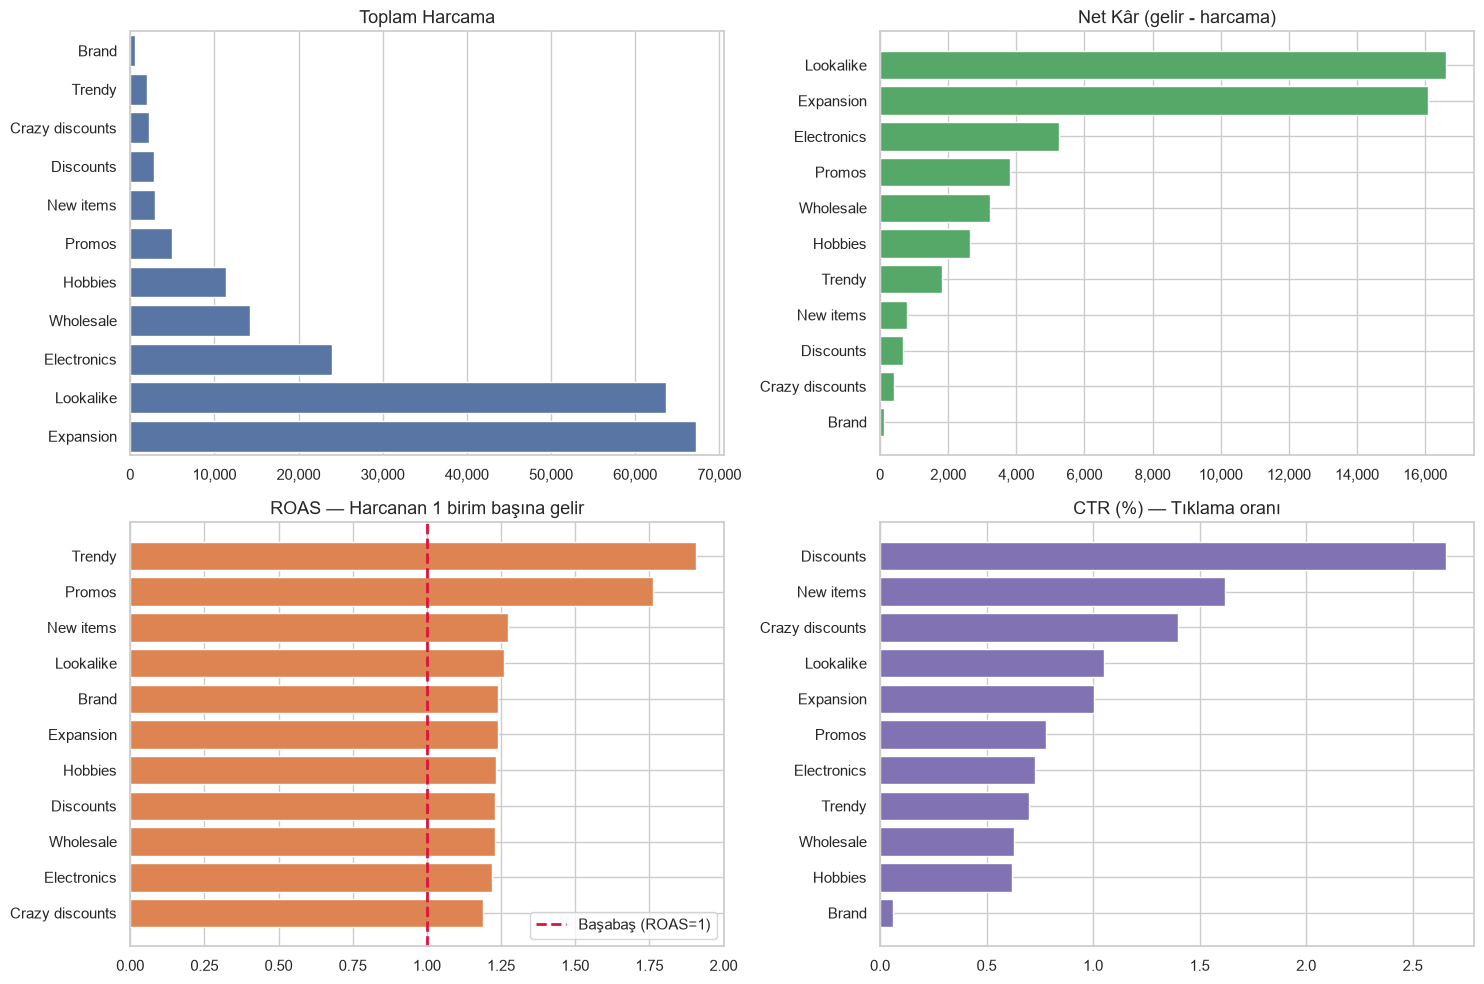

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
k = kampanya.reset_index()

# Harcama
sns.barplot(data=k.sort_values('harcama'), y='campaign_name', x='harcama',
            ax=ax[0,0], color='#4C72B0')
ax[0,0].set_title('Toplam Harcama'); ax[0,0].set_ylabel(''); ax[0,0].set_xlabel('')
ax[0,0].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Kâr
kar_sirali = k.sort_values('kar')
renkler = ['#C44E52' if v < 0 else '#55A868' for v in kar_sirali['kar']]
ax[0,1].barh(kar_sirali['campaign_name'], kar_sirali['kar'], color=renkler)
ax[0,1].set_title('Net Kâr (gelir - harcama)')
ax[0,1].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# ROAS
roas_sirali = k.sort_values('roas')
ax[1,0].barh(roas_sirali['campaign_name'], roas_sirali['roas'], color='#DD8452')
ax[1,0].axvline(1.0, color='crimson', ls='--', lw=2, label='Başabaş (ROAS=1)')
ax[1,0].set_title('ROAS — Harcanan 1 birim başına gelir'); ax[1,0].legend()

# CTR
ctr_sirali = k.sort_values('ctr')
ax[1,1].barh(ctr_sirali['campaign_name'], ctr_sirali['ctr'] * 100, color='#8172B3')
ax[1,1].set_title('CTR (%) — Tıklama oranı')

plt.tight_layout(); plt.show()

### 5.2 Bütçe konsantrasyonu (Pareto analizi)

Harcamanın kaç kampanyada toplandığını görmek, risk değerlendirmesi için kritiktir. Bütçenin %80'i iki kampanyadaysa, o kampanyalardan biri bozulduğunda tüm hesap sarsılır.

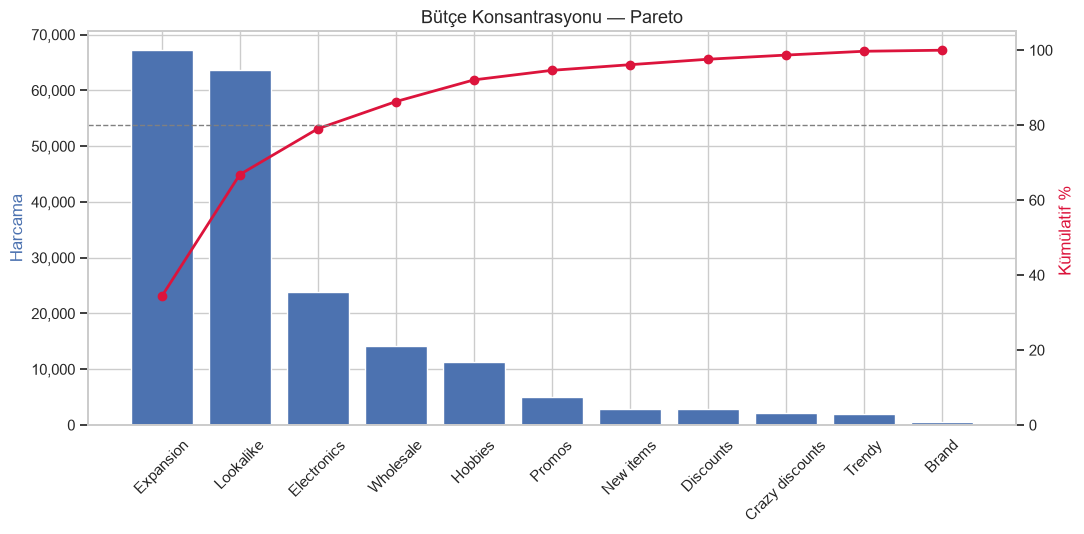

,harcama,pay_%,kumulatif_%
campaign_name,,,
Expansion,"67,212.82",34.33,34.33
Lookalike,"63,631.09",32.50,66.84
Electronics,"23,920.42",12.22,79.06
Wholesale,"14,181.71",7.24,86.30
Hobbies,"11,326.97",5.79,92.09
Promos,"4,993.84",2.55,94.64
New items,"2,936.97",1.50,96.14
Discounts,"2,856.39",1.46,97.60
Crazy discounts,"2,175.29",1.11,98.71


In [23]:
pareto = kampanya[['harcama']].sort_values('harcama', ascending=False).copy()
pareto['pay_%']      = pareto['harcama'] / pareto['harcama'].sum() * 100
pareto['kumulatif_%'] = pareto['pay_%'].cumsum()

fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax1.bar(pareto.index, pareto['harcama'], color='#4C72B0')
ax1.set_ylabel('Harcama', color='#4C72B0')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(pareto.index, pareto['kumulatif_%'], color='crimson', marker='o', lw=2)
ax2.axhline(80, color='gray', ls='--', lw=1)
ax2.set_ylabel('Kümülatif % ', color='crimson')
ax2.set_ylim(0, 105); ax2.grid(False)

plt.title('Bütçe Konsantrasyonu — Pareto')
plt.tight_layout(); plt.show()

pareto.round(2)

### 5.3 Verimlilik matrisi: nereye para dökülüyor, nereden geri geliyor?

Bu grafik bütçe kararının kalbidir. Dört çeyreğe bakın:

- **Sağ-üst (çok harcama + yüksek ROAS):** Yıldızlar — koru, ölçeklendir
- **Sol-üst (az harcama + yüksek ROAS):** Gizli mücevherler — **bütçe artırılacak yer burası**
- **Sağ-alt (çok harcama + düşük ROAS):** Risk — incelenmeli, kısılmalı
- **Sol-alt (az harcama + düşük ROAS):** Önemsiz — kapatılabilir

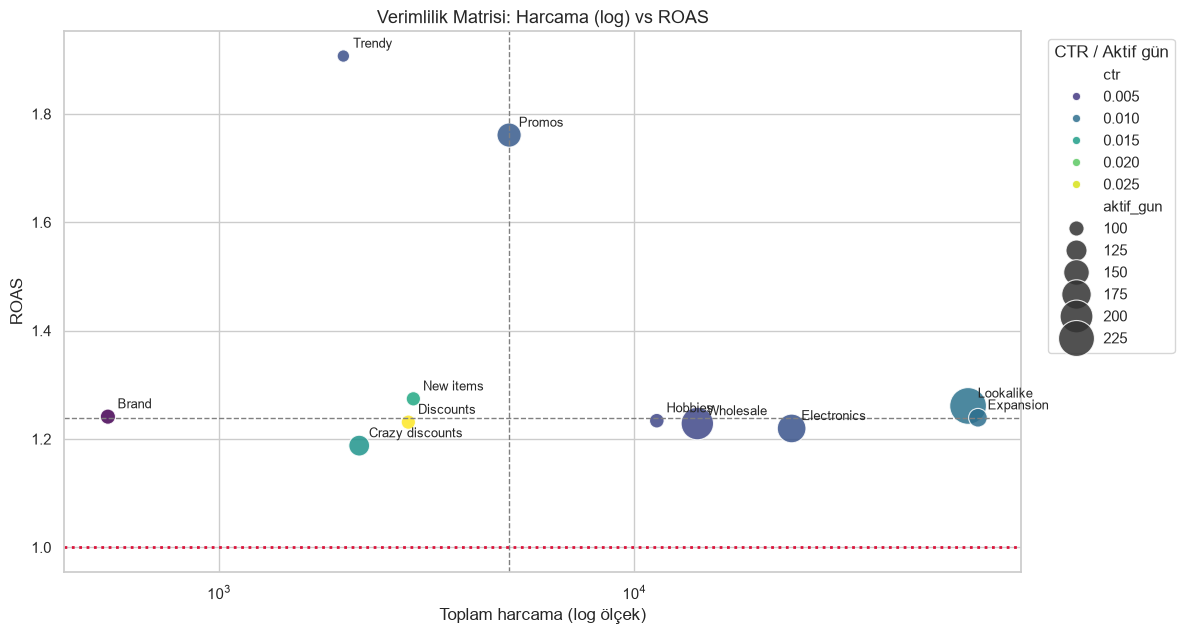

In [24]:
fig, ax = plt.subplots(figsize=(12, 6.5))

sns.scatterplot(data=k, x='harcama', y='roas', size='aktif_gun', hue='ctr',
                sizes=(80, 700), palette='viridis', ax=ax, alpha=.85)

ax.axhline(kampanya['roas'].median(), color='gray', ls='--', lw=1)
ax.axvline(kampanya['harcama'].median(), color='gray', ls='--', lw=1)
ax.axhline(1.0, color='crimson', ls=':', lw=2)

for _, r in k.iterrows():
    ax.annotate(r['campaign_name'], (r['harcama'], r['roas']),
                fontsize=9, xytext=(7, 6), textcoords='offset points')

ax.set_xscale('log')   # harcamalar 500 ile 67.000 arasında -> log ölçek şart
ax.set_title('Verimlilik Matrisi: Harcama (log) vs ROAS')
ax.set_xlabel('Toplam harcama (log ölçek)'); ax.set_ylabel('ROAS')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='CTR / Aktif gün')
plt.tight_layout(); plt.show()

> 💡 **Neden log ölçek?** `Brand` 540, `Expansion` 67.000 harcamış — 124 kat fark. Normal ölçekte küçük kampanyaların hepsi sol kenarda üst üste yığılır ve hiçbir şey okunmaz. Log ölçek oransal farkları görünür kılar.

### 5.4 Zaman içinde performans

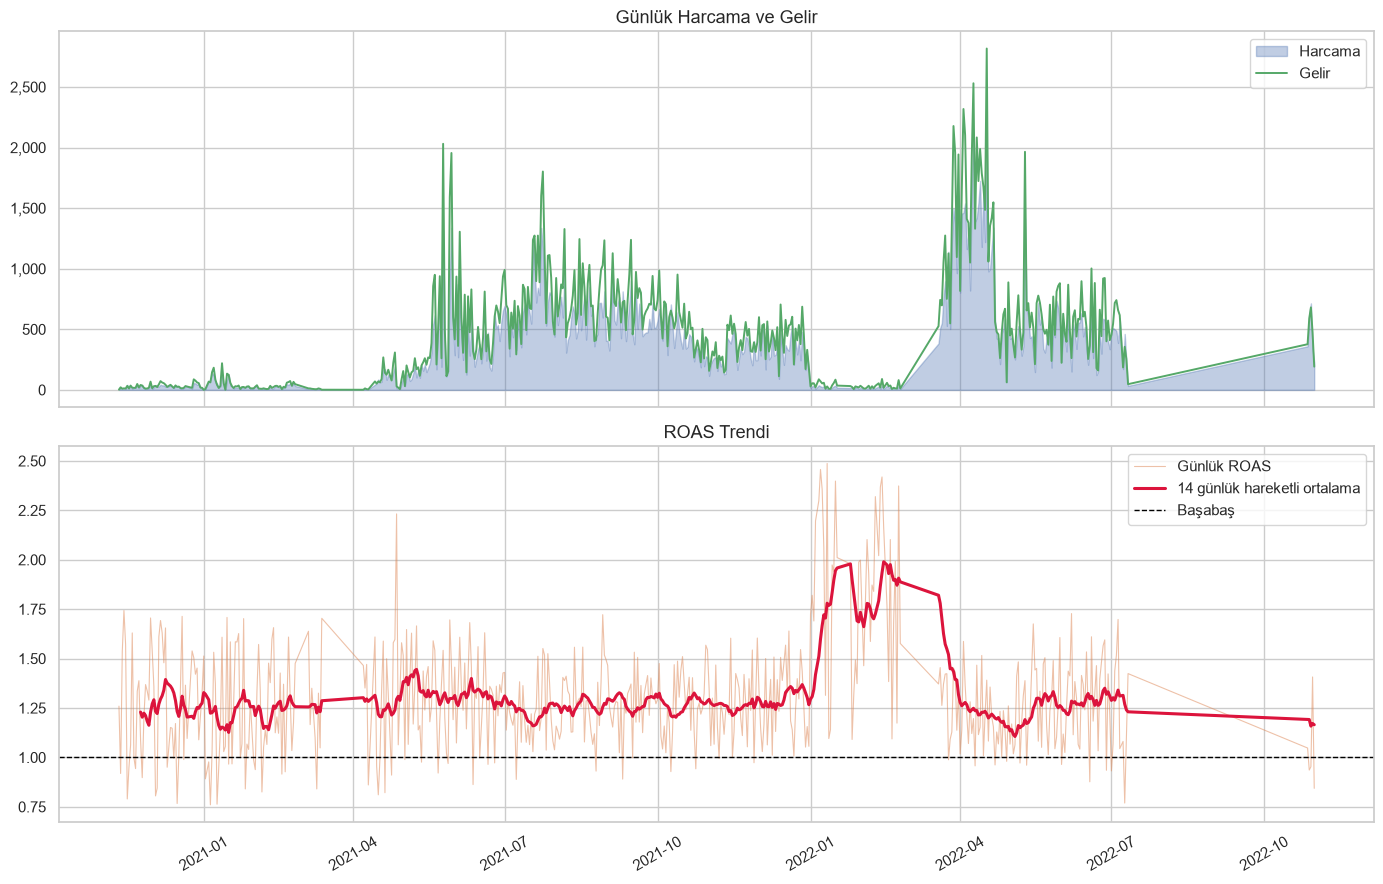

In [25]:
gunluk = (aktif.groupby('ad_date')
          .agg(harcama=('total_spend', 'sum'), gelir=('total_value', 'sum'))
          .assign(roas=lambda d: d['gelir'] / d['harcama']))

fig, ax = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax[0].fill_between(gunluk.index, gunluk['harcama'], alpha=.35, color='#4C72B0', label='Harcama')
ax[0].plot(gunluk.index, gunluk['gelir'], color='#55A868', lw=1.4, label='Gelir')
ax[0].set_title('Günlük Harcama ve Gelir'); ax[0].legend()
ax[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

ax[1].plot(gunluk.index, gunluk['roas'], color='#DD8452', lw=.8, alpha=.5, label='Günlük ROAS')
ax[1].plot(gunluk.index, gunluk['roas'].rolling(14).mean(), color='crimson', lw=2.2,
           label='14 günlük hareketli ortalama')
ax[1].axhline(1.0, color='black', ls='--', lw=1, label='Başabaş')
ax[1].set_title('ROAS Trendi'); ax[1].legend()
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

> 💡 **Neden hareketli ortalama?** Günlük ROAS çok gürültülüdür — tek bir iyi gün trendi değiştirmez. 14 günlük pencere gürültüyü bastırıp asıl yönü gösterir. Ham veriyi soluk, hareketli ortalamayı kalın çizmek okuyucuya "asıl buna bak" demenin görsel yoludur.

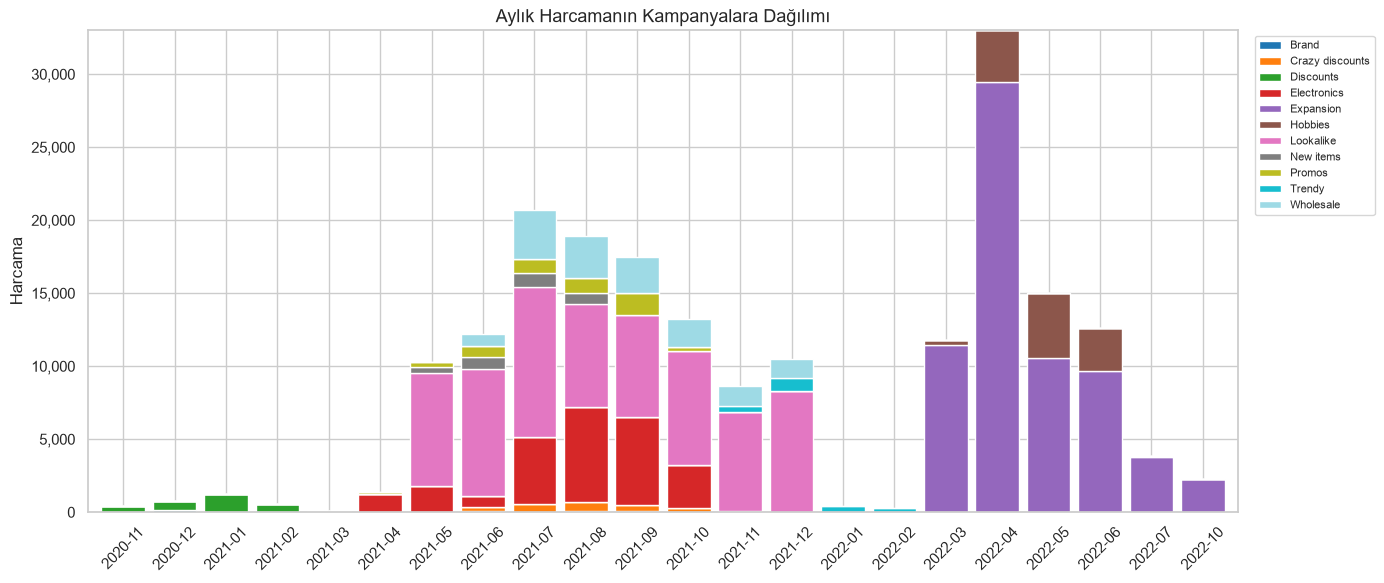

In [26]:
# Aylık kampanya harcaması - hangi kampanya ne zaman aktifti?
aylik = aktif.pivot_table(index='ay', columns='campaign_name',
                          values='total_spend', aggfunc='sum').fillna(0)

aylik.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20', width=.85)
plt.title('Aylık Harcamanın Kampanyalara Dağılımı')
plt.ylabel('Harcama'); plt.xlabel('')
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

### 5.5 Kampanyaların günlük ROAS dağılımı

Ortalama tek başına yanıltıcıdır. Boxplot **tutarlılığı** gösterir: dar bir kutu "öngörülebilir kampanya", geniş kutu "kumar" demektir.

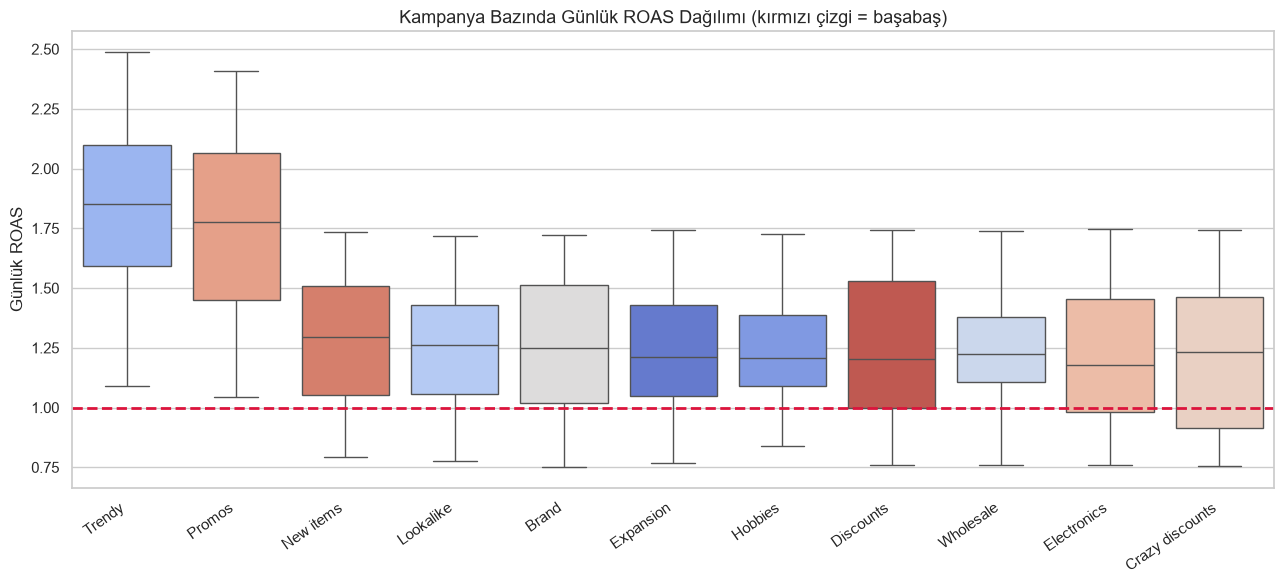

,ortalama,medyan,std,min,max,degiskenlik
campaign_name,,,,,,
Wholesale,1.24,1.22,0.20,0.76,1.74,0.16
Hobbies,1.24,1.21,0.21,0.84,1.73,0.17
Trendy,1.84,1.85,0.35,1.09,2.49,0.19
Lookalike,1.25,1.26,0.24,0.78,1.72,0.19
Expansion,1.24,1.21,0.24,0.77,1.75,0.20
New items,1.28,1.30,0.27,0.79,1.73,0.21
Promos,1.75,1.78,0.39,1.04,2.41,0.22
Brand,1.24,1.25,0.28,0.75,1.72,0.23
Discounts,1.25,1.21,0.29,0.76,1.74,0.23


In [27]:
sira = kampanya.sort_values('roas', ascending=False).index

plt.figure(figsize=(13, 6))
sns.boxplot(data=aktif, x='campaign_name', y='roas', order=sira,
            hue='campaign_name', palette='coolwarm', legend=False)
plt.axhline(1.0, color='crimson', ls='--', lw=2)
plt.title('Kampanya Bazında Günlük ROAS Dağılımı (kırmızı çizgi = başabaş)')
plt.xlabel(''); plt.ylabel('Günlük ROAS')
plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.show()

aktif.groupby('campaign_name')['roas'].agg(
    ortalama='mean', medyan='median', std='std',
    min='min', max='max'
).assign(degiskenlik=lambda d: (d['std'] / d['ortalama']).round(3)) \
 .sort_values('degiskenlik').round(3)

**Değişkenlik katsayısı** (std ÷ ortalama) risk ölçüsüdür. Düşük olan kampanyalar öngörülebilir; yüksek olanlar bazı günler parlıyor bazı günler batıyor. Bütçe artırırken düşük değişkenlikli olanları tercih edin.

### 5.6 Metrikler arası ilişki

Yüksek CTR her zaman yüksek kâr demek mi? Pazarlamada "vanity metric" (gösteriş metriği) tuzağı tam buradadır.

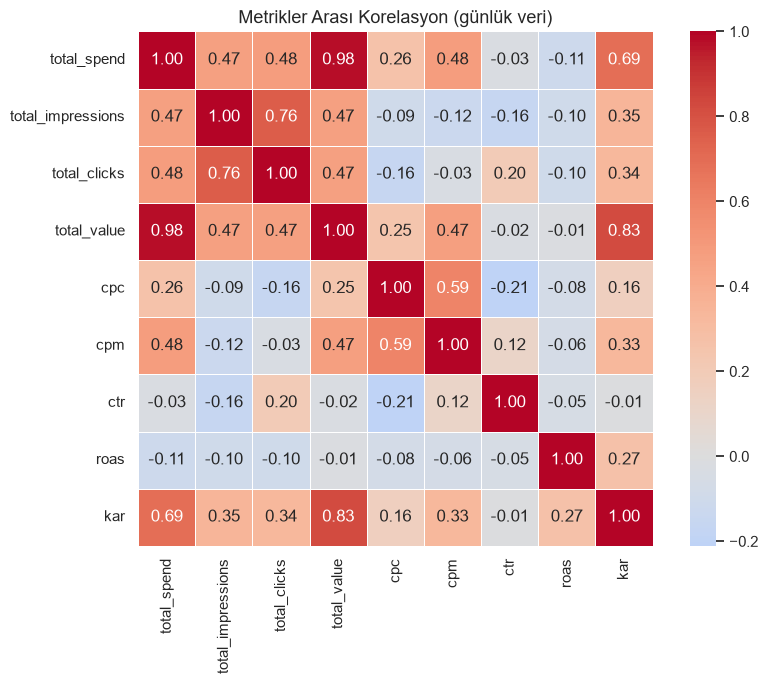

CTR ile ROAS korelasyonu : -0.05
CPC ile ROAS korelasyonu : -0.077
Harcama ile kâr          : 0.691


In [28]:
sayisal = ['total_spend', 'total_impressions', 'total_clicks', 'total_value',
           'cpc', 'cpm', 'ctr', 'roas', 'kar']

plt.figure(figsize=(9, 7))
sns.heatmap(aktif[sayisal].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=.5)
plt.title('Metrikler Arası Korelasyon (günlük veri)')
plt.tight_layout(); plt.show()

print('CTR ile ROAS korelasyonu :', round(aktif['ctr'].corr(aktif['roas']), 3))
print('CPC ile ROAS korelasyonu :', round(aktif['cpc'].corr(aktif['roas']), 3))
print('Harcama ile kâr          :', round(aktif['total_spend'].corr(aktif['kar']), 3))

### 5.7 Haftanın günü etkisi

Bütçe planlaması için: hangi günler daha verimli?

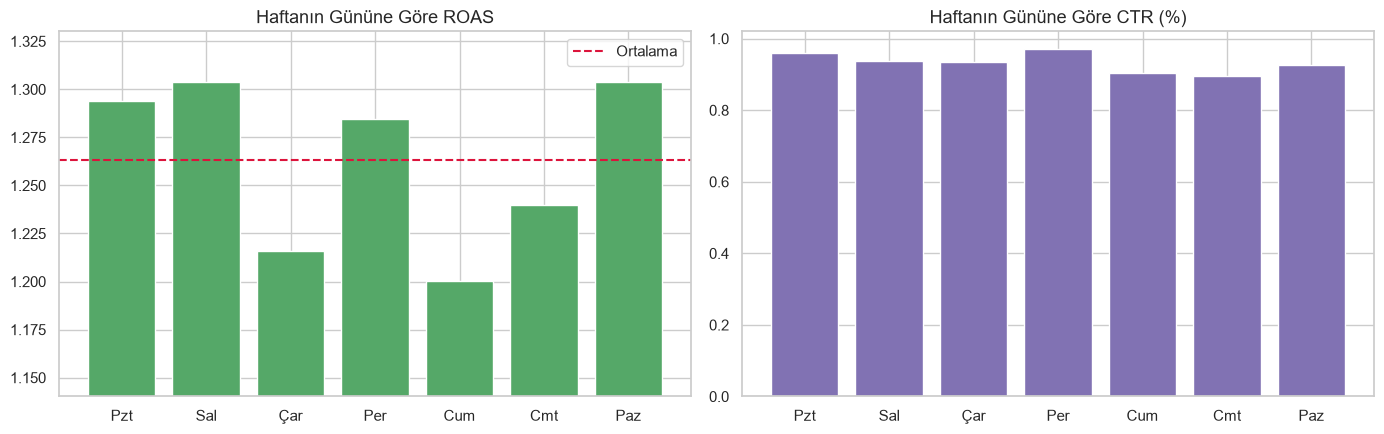

,harcama,gelir,gosterim,tiklama,roas,ctr
hafta_gunu,,,,,,
Pzt,"26,938.13","34,860.30",7501320,72080,1.29,0.01
Sal,"28,632.50","37,337.19",7046963,65988,1.30,0.01
Çar,"28,730.16","34,933.56",7307921,68389,1.22,0.01
Per,"24,387.06","31,320.67",6759128,65657,1.28,0.01
Cum,"27,990.83","33,595.03",6836204,61875,1.20,0.01
Cmt,"29,452.90","36,512.44",7463862,66749,1.24,0.01
Paz,"29,636.15","38,634.24",8164734,75610,1.30,0.01


In [29]:
gun_sira = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
gun_tr = dict(zip(gun_sira, ['Pzt','Sal','Çar','Per','Cum','Cmt','Paz']))

haftalik = (aktif.groupby('hafta_gunu')
            .agg(harcama=('total_spend','sum'), gelir=('total_value','sum'),
                 gosterim=('total_impressions','sum'), tiklama=('total_clicks','sum'))
            .reindex(gun_sira))
haftalik['roas'] = haftalik['gelir'] / haftalik['harcama']
haftalik['ctr']  = haftalik['tiklama'] / haftalik['gosterim']
haftalik.index = haftalik.index.map(gun_tr)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(haftalik.index, haftalik['roas'], color='#55A868')
ax[0].axhline(haftalik['roas'].mean(), color='crimson', ls='--', label='Ortalama')
ax[0].set_title('Haftanın Gününe Göre ROAS'); ax[0].legend()
ax[0].set_ylim(haftalik['roas'].min()*0.95, haftalik['roas'].max()*1.02)

ax[1].bar(haftalik.index, haftalik['ctr']*100, color='#8172B3')
ax[1].set_title('Haftanın Gününe Göre CTR (%)')

plt.tight_layout(); plt.show()
haftalik.round(4)

> ⚠️ **Y ekseni uyarısı:** Sol grafikte ekseni kestim (`set_ylim`) çünkü farklar küçük ve sıfırdan başlayan eksende hiçbir şey görünmüyordu. Ama bu **abartma riski** taşır — küçük bir farkı dramatik gösterebilir. Sunumda bunu mutlaka belirtin, aksi halde yanıltıcı olur.

---
## 6. Sonuçları dışa aktarma

In [30]:
kampanya_rapor = kampanya[['aktif_gun', 'ilk_gun', 'son_gun', 'harcama', 'gelir',
                           'kar', 'roas', 'romi', 'gosterim', 'tiklama',
                           'ctr', 'cpc', 'cpm', 'gunluk_harcama']].copy()
kampanya_rapor = kampanya_rapor.round({c: 4 for c in kampanya_rapor.select_dtypes('number').columns})

kampanya_rapor.to_csv('kampanya_performans.csv', encoding='utf-8-sig')
fb.to_csv('facebook_ads_temiz.csv', index=False, encoding='utf-8-sig')

print('kampanya_performans.csv :', kampanya_rapor.shape)
print('facebook_ads_temiz.csv  :', fb.shape)
kampanya_rapor

kampanya_performans.csv : (11, 14)
facebook_ads_temiz.csv  : (1494, 17)


,aktif_gun,ilk_gun,son_gun,harcama,gelir,kar,roas,romi,gosterim,tiklama,ctr,cpc,cpm,gunluk_harcama
campaign_name,,,,,,,,,,,,,,
Lookalike,232,2021-05-14,2021-12-31,"63,631.09","80,234.70","16,603.61",1.26,0.26,21019388,220993,0.01,0.29,3.03,274.27
Expansion,114,2022-03-19,2022-10-31,"67,212.82","83,288.66","16,075.84",1.24,0.24,3736092,37469,0.01,1.79,17.99,589.59
Electronics,170,2021-04-14,2021-10-18,"23,920.42","29,169.38","5,248.96",1.22,0.22,7070770,51593,0.01,0.46,3.38,140.71
Promos,142,2021-04-24,2021-10-05,"4,993.84","8,793.77","3,799.93",1.76,0.76,2216422,17315,0.01,0.29,2.25,35.17
Wholesale,197,2021-06-17,2021-12-31,"14,181.71","17,421.33","3,239.62",1.23,0.23,2902356,18185,0.01,0.78,4.89,71.99
Hobbies,98,2022-03-26,2022-07-01,"11,326.97","13,974.63","2,647.66",1.23,0.23,8146187,50611,0.01,0.22,1.39,115.58
Trendy,91,2021-11-13,2022-02-24,"1,992.31","3,798.90","1,806.59",1.91,0.91,1392189,9725,0.01,0.20,1.43,21.89
New items,97,2021-05-12,2021-08-25,"2,936.97","3,742.05",805.08,1.27,0.27,1045294,16935,0.02,0.17,2.81,30.28
Discounts,97,2020-11-11,2021-02-25,"2,856.39","3,516.27",659.88,1.23,0.23,1256069,33353,0.03,0.09,2.27,29.45


---
## 7. Marketing ekibine sunulacak bulgular

In [31]:
en_karli    = kampanya['kar'].idxmax()
en_verimli  = kampanya['roas'].idxmax()
en_zayif    = kampanya['roas'].idxmin()
ilk_iki_pay = pareto['pay_%'].head(2).sum()

print('=' * 58)
print('FACEBOOK REKLAM ANALİZİ — ÖZET')
print('=' * 58)
print(f"Analiz dönemi          : {fb['ad_date'].min():%d.%m.%Y} - {fb['ad_date'].max():%d.%m.%Y}")
print(f"Kampanya sayısı        : {fb['campaign_name'].nunique()}")
print(f"Aktif reklam günü      : {fb['aktif'].sum():,}  (pasif: {(~fb['aktif']).sum()})")
print('-' * 58)
print(f"Toplam harcama         : {T_harcama:,.0f}")
print(f"Toplam gelir           : {T_gelir:,.0f}")
print(f"Net kâr                : {T_gelir - T_harcama:,.0f}")
print(f"Genel ROAS             : {T_gelir / T_harcama:.3f}  (her 1 birim -> {T_gelir/T_harcama:.2f} birim)")
print(f"Gerçek ROMI            : %{(T_gelir/T_harcama - 1)*100:.1f}")
print('-' * 58)
print(f"En yüksek kâr          : {en_karli} ({kampanya.loc[en_karli,'kar']:,.0f})")
print(f"En verimli (ROAS)      : {en_verimli} ({kampanya.loc[en_verimli,'roas']:.3f})")
print(f"En zayıf (ROAS)        : {en_zayif} ({kampanya.loc[en_zayif,'roas']:.3f})")
print(f"Zarar eden kampanya    : {(kampanya['kar'] < 0).sum()}")
print(f"İlk 2 kampanyanın payı : %{ilk_iki_pay:.1f} (bütçe konsantrasyonu)")
print('=' * 58)

FACEBOOK REKLAM ANALİZİ — ÖZET
Analiz dönemi          : 11.11.2020 - 05.11.2022
Kampanya sayısı        : 11
Aktif reklam günü      : 1,462  (pasif: 32)
----------------------------------------------------------
Toplam harcama         : 195,768
Toplam gelir           : 247,193
Net kâr                : 51,426
Genel ROAS             : 1.263  (her 1 birim -> 1.26 birim)
Gerçek ROMI            : %26.3
----------------------------------------------------------
En yüksek kâr          : Lookalike (16,604)
En verimli (ROAS)      : Trendy (1.907)
En zayıf (ROAS)        : Crazy discounts (1.188)
Zarar eden kampanya    : 0
İlk 2 kampanyanın payı : %66.8 (bütçe konsantrasyonu)


### 📌 Bulgular ve bütçe önerileri

**1. Hesabın tamamı kârlı ama marj dar.**
Genel ROAS ~1.26 — harcanan her 1 birim 1.26 birim gelir getiriyor. Bu **brüt** bir rakam: ürün maliyeti, kargo, iade ve operasyon dahil değil. Brüt marjınız %25'in altındaysa bu hesap aslında **zarar ediyor** demektir. Marketing ekibine ilk sorulacak soru budur.

**2. Bütçe iki kampanyada aşırı yoğunlaşmış.**
`Expansion` ve `Lookalike` toplam harcamanın üçte ikisinden fazlasını alıyor ve ikisinin de ROAS'ı ortalamanın hemen **altında** (~1.24-1.26). Yani paranın çoğu en verimli yere gitmiyor.

**3. Küçük ama yüksek verimli kampanyalar var.**
`Trendy` (ROAS 1.91) ve `Promos` (1.76) hesabın en verimli kampanyaları — ama ikisi birlikte toplam bütçenin sadece %3'ünü almış. **Somut öneri:** Bu iki kampanyanın bütçesini kademeli artırıp ROAS'ın korunup korunmadığını test edin. Ölçek büyüdükçe verim düşme eğilimindedir, bu yüzden tek seferde değil **kademeli** artırın.

**4. `romi` sütunu yanlış adlandırılmış.**
Veri setindeki `romi` aslında ROAS. Bir yönetici "ROMI 1.26" ifadesini "%126 kâr" diye okursa gerçekte %26 olan getiriyi beş katı sanır. Veri sözlüğü düzeltilmeli.

**5. Kampanya süreklilikleri çok farklı.**
`Brand` bir yıla yayılmış ama sadece %30 gün kapsamıyla; `Lookalike` kesintisiz çalışmış. Bu kampanyaları aynı tabloda karşılaştırırken bunu not düşün — aralıklı çalışan bir kampanyanın "öğrenme fazı" her yeniden başlatmada sıfırlanır ve verimi düşer.

**6. Veri sadece 2022 Kasım'a kadar.**
En yeni veri 05.11.2022. Bugün alınacak bütçe kararları için güncel veri talep edilmeli.
